In [ ]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import openmc
import openmc.data


N_PARTICLES = 1_000_000
N_BATCHES = 100
SOURCE_ENERGY = 14.0e6
CUBOID_SIZE = 50.0

In [ ]:
model = openmc.Model()
iron = openmc.Material(name='Natural Iron')
iron.add_element('Fe', 1.0)
iron.set_density('g/cm3', 7.874)
model.materials = openmc.Materials([iron])

half = CUBOID_SIZE / 2
x_min = openmc.XPlane(-half, boundary_type='vacuum')
x_max = openmc.XPlane(half, boundary_type='vacuum')
y_min = openmc.YPlane(-half, boundary_type='vacuum')
y_max = openmc.YPlane(half, boundary_type='vacuum')
z_min = openmc.ZPlane(-half, boundary_type='vacuum')
z_max = openmc.ZPlane(half, boundary_type='vacuum')
cell = openmc.Cell(fill=iron, region=+x_min & -x_max & +y_min & -y_max & +z_min & -z_max)
all_surfaces = [x_min, x_max, y_min, y_max, z_min, z_max]
model.geometry = openmc.Geometry([cell])

model.settings.run_mode = 'fixed source'
model.settings.batches = N_BATCHES
model.settings.particles = N_PARTICLES
model.settings.photon_transport = True
model.settings.electron_treatment = 'led'
model.settings.output = {'tallies': False, 'summary': False}


source = openmc.IndependentSource()
source.particle = 'neutron'
source.space = openmc.stats.Box(
    lower_left=(-half + 0.1, -half + 0.1, -half + 0.01),
    upper_right=(half - 0.1, half - 0.1, -half + 0.02),
)
source.angle = openmc.stats.PolarAzimuthal(
    mu=openmc.stats.Uniform(0.0, 1.0),
    phi=openmc.stats.Uniform(0.0, 2 * np.pi),
    reference_uvw=(0.0, 0.0, 1.0),
)
source.energy = openmc.stats.Discrete([SOURCE_ENERGY], [1.0])
model.settings.source = source

In [3]:
tallies = openmc.Tallies()
cell_filter = openmc.CellFilter([cell])
surface_filter = openmc.SurfaceFilter(all_surfaces)
cellfrom_filter = openmc.CellFromFilter([cell])
neutron_filter = openmc.ParticleFilter(['neutron'])
photon_filter = openmc.ParticleFilter(['photon'])
energy_filter = openmc.EnergyFilter(np.logspace(-5, np.log10(20e6), 201))

heating = openmc.Tally(name='heating')
heating.filters = [cell_filter]
heating.scores = ['heating']
tallies.append(heating)

leak_n = openmc.Tally(name='leakage_neutron')
leak_n.filters = [cellfrom_filter, surface_filter, neutron_filter, energy_filter]
leak_n.scores = ['current']
tallies.append(leak_n)

leak_p = openmc.Tally(name='leakage_photon')
leak_p.filters = [cellfrom_filter, surface_filter, photon_filter, energy_filter]
leak_p.scores = ['current']
tallies.append(leak_p)

capture = openmc.Tally(name='capture_rate')
capture.filters = [cell_filter, neutron_filter]
capture.nuclides = [entry[0] for entry in iron.nuclides]
capture.scores = ['(n,gamma)']
tallies.append(capture)
model.tallies = tallies

In [ ]:
model.export_to_model_xml('model.xml')
model.run(cwd='.', output=False)

In [ ]:
sp = openmc.StatePoint(f'statepoint.{N_BATCHES}.h5')
A = SOURCE_ENERGY
heat_tally = sp.get_tally(name='heating')
B = heat_tally.mean.sum()
B_std = np.sqrt(np.sum(heat_tally.std_dev**2))


def compute_leakage(tally):
    data = tally.get_pandas_dataframe()
    energy = np.sqrt(data['energy low [eV]'] * data['energy high [eV]'])
    current = np.abs(data['mean'])
    return (energy * current).sum(), np.sqrt(np.sum((energy * data['std. dev.'])**2))


C_n, C_n_std = compute_leakage(sp.get_tally(name='leakage_neutron'))
C_p, C_p_std = compute_leakage(sp.get_tally(name='leakage_photon'))
C = C_n + C_p
C_std = np.hypot(C_n_std, C_p_std)

In [ ]:
D = B + C - A
D_std = np.hypot(B_std, C_std)

Q_ng = {
        'Fe54': openmc.data.IncidentNeutron.from_hdf5(openmc.data.DataLibrary.from_xml().get_by_material("Fe54")["path"]).reactions[102].q_value, 
        'Fe56': openmc.data.IncidentNeutron.from_hdf5(openmc.data.DataLibrary.from_xml().get_by_material("Fe56")["path"]).reactions[102].q_value, 
        'Fe57': openmc.data.IncidentNeutron.from_hdf5(openmc.data.DataLibrary.from_xml().get_by_material("Fe57")["path"]).reactions[102].q_value, 
        'Fe58': openmc.data.IncidentNeutron.from_hdf5(openmc.data.DataLibrary.from_xml().get_by_material("Fe58")["path"]).reactions[102].q_value
        }

capture_data = sp.get_tally(name='capture_rate').get_pandas_dataframe()
E_ng = 0.0
E_ng_var = 0.0
for _, row in capture_data.iterrows():
    if row['nuclide'] in Q_ng:
        q_value = Q_ng[row['nuclide']]
        E_ng += row['mean'] * q_value
        E_ng_var += (row['std. dev.'] * q_value)**2
E_ng_std = np.sqrt(E_ng_var)
sp.close()

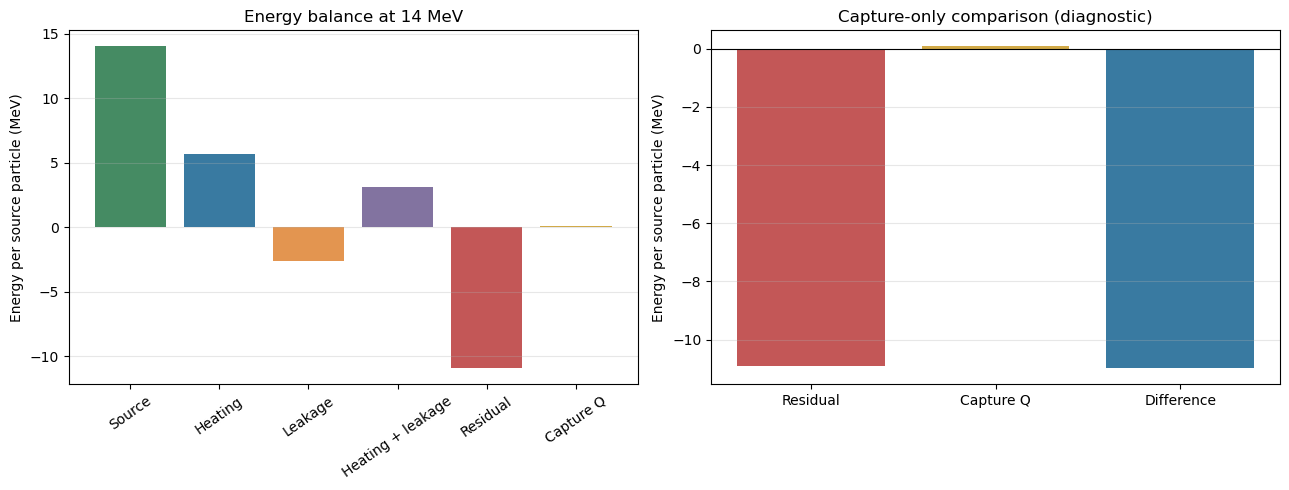

A (source): 14.0000 MeV
B (heating): 5.6712 MeV
C (leakage): -2.5796 MeV
D = B + C - A: -10.9083 MeV
Capture Q estimate: +0.0770 MeV
Difference: -10.9854 MeV
Interpretation: capture-only closure does not establish total energy conservation; see energy_balance_14MeV_analysis.txt.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Source', 'Heating', 'Leakage', 'Heating + leakage', 'Residual', 'Capture Q']
values = np.array([A, B, C, B + C, D, E_ng]) / 1e6
axes[0].bar(labels, values, color=['#458b63', '#397aa1', '#e39550', '#8273a0', '#c35757', '#d2aa48'])
axes[0].set_ylabel('Energy per source particle (MeV)')
axes[0].set_title(f'Energy balance at {SOURCE_ENERGY / 1e6:g} MeV')
axes[0].tick_params(axis='x', labelrotation=35)
axes[0].grid(axis='y', alpha=0.3)

comparison = np.array([D, E_ng, D - E_ng]) / 1e6
axes[1].bar(['Residual', 'Capture Q', 'Difference'], comparison,
            color=['#c35757', '#d2aa48', '#397aa1'])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Energy per source particle (MeV)')
axes[1].set_title('Capture-only comparison (diagnostic)')
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig('7225_ce_1.png', dpi=150)

Path('energy_balance_report.txt').write_text(
f'A (source): {A / 1e6:.4f} MeV\n'
f'B (heating): {B / 1e6:.4f} MeV\n'
f'C (leakage): {C / 1e6:.4f} MeV\n'
f'D = B + C - A: {D / 1e6:+.4f} MeV\n'
f'Capture Q estimate: {E_ng / 1e6:+.4f} MeV\n'
f'Difference: {(D - E_ng) / 1e6:+.4f} MeV\n'
)

In [ ]:
# This is a capture-only diagnostic, not a complete energy-conservation test.
# Check if the difference between D and E_ng is within an acceptable range 10 keV.
overall_pass = bool(np.isfinite(D - E_ng) and abs(D - E_ng) <= 10000)
Path('results.txt').write_text('PASS\n' if overall_pass else 'FAIL\n')
print(f'Capture-only diagnostic: {"PASS" if overall_pass else "FAIL"}')

Capture-only diagnostic: FAIL
